# RNN - Recurrent Neural Networks
---

## 1️⃣ Simple Neural Network (no time/sequence)

A **vanilla feedforward neural network** takes an input vector and passes it through weights, bias, and activation.

$$
h = \tanh(Wx + b)
$$

* Input: $x$ → just one vector (no sequence, e.g. an image feature vector).
* Output: $h$ → one result (hidden activation).
* **No memory** of the past → every input is processed independently.

---

## 2️⃣ Sequential Data (time steps appear)

Now suppose your input isn’t just one vector but a **sequence of vectors**:

$$
x_1, x_2, x_3, \dots, x_T
$$

Example: words in a sentence, stock prices over days, etc.

A simple NN would still treat each $x_t$ separately → not good, because sequences **depend on context**.

---

## 3️⃣ Add Recurrence (memory of the past)

To capture dependencies, we let the network carry **information from the past**.

At time step $t$:

* Take the current input $x_t$.
* Combine it with the **previous output** (or hidden state) $h_{t-1}$.
* Produce a new hidden state $h_t$.

Now the network has memory.

---

## 4️⃣ Full Hidden State Equation

That’s where the standard RNN update rule comes in:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

Where:

* $W_x$: weights for the current input
* $W_h$: weights for the previous hidden state
* $b$: bias
* $\tanh$: activation function
* $h_t$: hidden state at step $t$ (this is also the “memory” that gets passed forward)

---

## 5️⃣ Why This Matters

* Unlike feedforward NNs, RNNs **share parameters across time** ($W_x, W_h$).
* This makes them efficient for sequence modeling.
* $h_t$ is like a “summary” of everything seen up to time $t$.
* At the final step $T$, we often use $h_T$ for classification (e.g., sentiment analysis).

---



# Example RNN - IMDB Sentiment Classification

## Import necessary library

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

## 1. Load dataset (IMDB sentiment classification)

In [2]:
# 1. Load dataset (IMDB sentiment classification)
max_features = 10000   # number of unique words to keep
maxlen = 200           # cut texts after 200 words

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Print the shape of the training and testing data, and the maximum input feature size.

In [3]:
print("Shape of training data")
print(x_train.shape)
print("Shape of test data")
print(x_test.shape)

# Find the maximum input feature size
max_input_feature_size = max([max(sequence) for sequence in x_train])
print(f"Maximum input feature size or in this case maximum review size: {max_input_feature_size}")

(25000,)
(25000,)
Maximum input feature size: 9999


Display the first few training reviews, represented as sequences of integers.

In [4]:
print("First 5 input data from x_train")
x_train[:5]

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [5]:
print("First 5 label data from y_train")
y_train[:5]


array([1, 0, 0, 1, 0])

In [6]:
# Get the mapping of word -> integer index
word_index = imdb.get_word_index()


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Vocabulary or dictionary based on which label encoding was done for the reviews.

In [7]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [8]:
word_index.get('could')

97

Reverse engineering label encodings to actual words in eglish to understand how a single comment looks like.

In [9]:
# Reverse mapping: integer index -> word
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# Function to decode a review
def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_review])

# Example: show first training review
print("Encoded review:", x_train[0][:200])   # first 20 tokens
print("Decoded review:", decode_review(x_train[0][:200]))
print("Label:", "Positive" if y_train[0] == 1 else "Negative")


Encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16]
Decoded review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the pa

In [10]:
reverse_word_index.get(97)

'make'

Taking a random review and checking its size to see that all reviews are of not same six=ze and we have to pad sequences to bring them all to same size.

In [11]:
print(x_train[500])
print(len(x_train[500]))

[1, 5, 198, 138, 254, 8, 967, 10, 10, 39, 4, 1158, 213, 7, 650, 7660, 1475, 213, 7, 650, 13, 215, 135, 13, 1583, 754, 2359, 133, 252, 50, 9, 49, 1104, 136, 32, 4, 1109, 304, 133, 1812, 21, 15, 191, 607, 4, 910, 552, 7, 229, 5, 226, 20, 198, 138, 10, 10, 241, 46, 7, 158]
60


In [12]:
y_train[:500]

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0])

Pad sequences so all have same length

In [14]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


Verify padded sequences

In [15]:
x_train[10]

array([ 764, 6075,    5, 1030,    8, 2973,   73,  469,  167, 2127,    2,
       1568,    6,   87,  841,   18,    4,   22,    4,  192,   15,   91,
          7,   12,  304,  273, 1004,    4, 1375, 1172, 2768,    2,   15,
          4,   22,  764,   55, 5773,    5,   14, 4233, 7444,    4, 1375,
        326,    7,    4, 4760, 1786,    8,  361, 1236,    8,  989,   46,
          7,    4, 2768,   45,   55,  776,    8,   79,  496,   98,   45,
        400,  301,   15,    4, 1859,    9,    4,  155,   15,   66,    2,
         84,    5,   14,   22, 1534,   15,   17,    4,  167,    2,   15,
         75,   70,  115,   66,   30,  252,    7,  618,   51,    9, 2161,
          4, 3130,    5,   14, 1525,    8, 6584,   15,    2,  165,  127,
       1921,    8,   30,  179, 2532,    4,   22,    9,  906,   18,    6,
        176,    7, 1007, 1005,    4, 1375,  114,    4,  105,   26,   32,
         55,  221,   11,   68,  205,   96,    5,    4,  192,   15,    4,
        274,  410,  220,  304,   23,   94,  205,  1

In [16]:
len(x_train[10])

200

## 2. Build RNN model

In [17]:
model = Sequential([
    Embedding(input_dim=max_features, output_dim=128, input_length=maxlen),
    SimpleRNN(64, activation="tanh"),
    Dense(1, activation="sigmoid")   # binary classification
])

model.build(input_shape=(None, maxlen)) # Build the model by specifying the input shape
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Compile model

In [18]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])


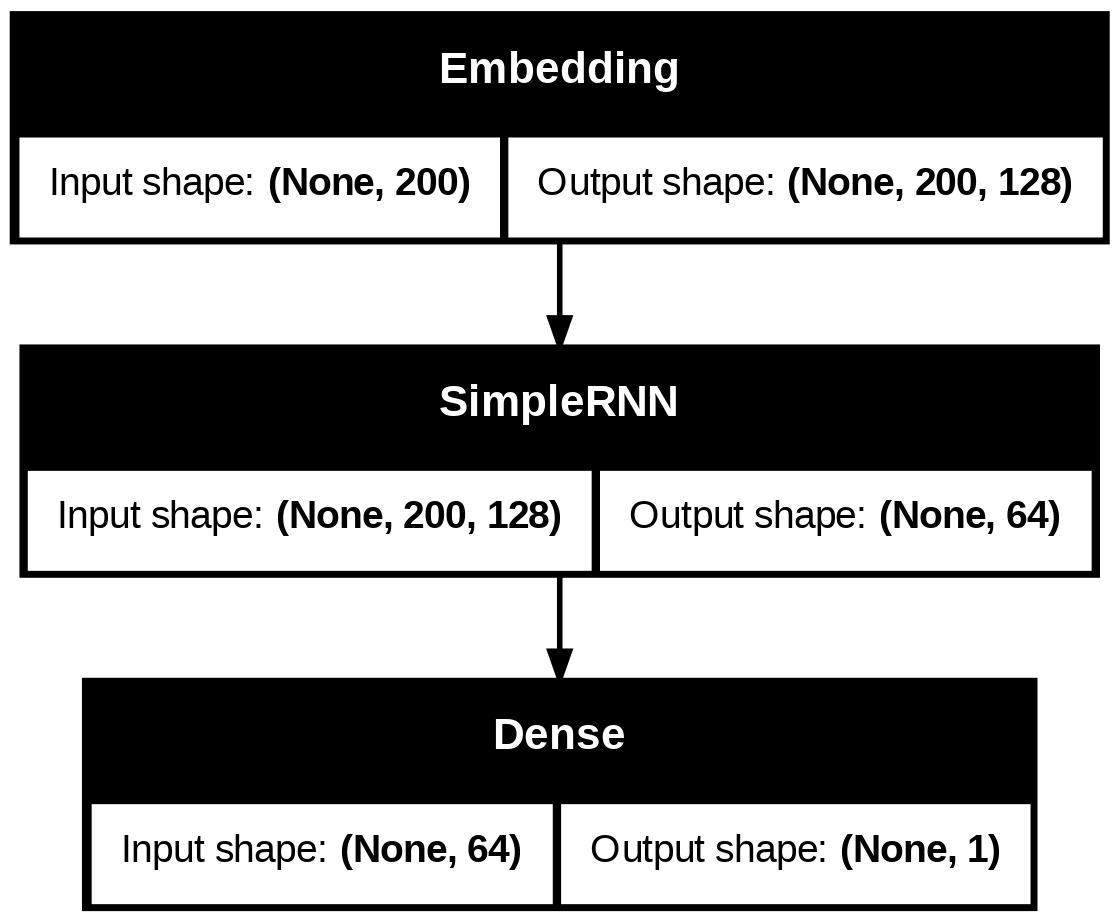

In [19]:
tf.keras.utils.plot_model(model, show_shapes=True)

## 4. Train model

In [20]:
history = model.fit(x_train, y_train,
                    epochs=3,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - accuracy: 0.5852 - loss: 0.6584 - val_accuracy: 0.8056 - val_loss: 0.4419
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - accuracy: 0.8259 - loss: 0.3938 - val_accuracy: 0.8262 - val_loss: 0.4188
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.8719 - loss: 0.3146 - val_accuracy: 0.8106 - val_loss: 0.4840


## 5. Evaluate

In [21]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.8110


In [22]:
prediction = model.predict(x_test)
prediction[0]

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step


array([0.36268747], dtype=float32)

## 6. Plot Embeddings - PCA Plot

In [ ]:
# 6. Build simple model with embedding
model = Sequential([
    Embedding(input_dim=max_features, output_dim=128, input_length=maxlen, name="embedding"),
    SimpleRNN(64, activation="tanh"),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=1, batch_size=512, validation_split=0.2)

In [ ]:
# 6.a. Extract embedding weights
embedding_layer = model.get_layer("embedding")
embedding_weights = embedding_layer.get_weights()[0]   # shape: (10000, 128)

# 6.b. Reduce dimensions (PCA)
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_weights[:500])  # take first 500 words

# 6.c. Get word index and reverse map
word_index = imdb.get_word_index()
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# 6.d. Plot
plt.figure(figsize=(12, 8))
plt.scatter(reduced[:,0], reduced[:,1], marker='.')
for i in range(1, 200):  # label first 200 words
    plt.text(reduced[i,0], reduced[i,1], reverse_word_index.get(i, "?"), fontsize=9)
plt.title("Word Embeddings (PCA Projection)")
plt.show()

## 7. Plot Embeddings - tSNE Plot

In [ ]:
# 7.a. Extract embedding weights
embedding_layer = model.get_layer("embedding")
embedding_weights = embedding_layer.get_weights()[0]   # shape: (10000, 128)

# 7.b. Reduce dimensions with t-SNE (use first 500 words for speed)
tsne = TSNE(n_components=2, perplexity=30, n_iter=2000, random_state=42, verbose=1)
reduced = tsne.fit_transform(embedding_weights[:500])

# 7.c. Reverse word index
word_index = imdb.get_word_index()
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# 7.d. Plot
plt.figure(figsize=(14, 10))
plt.scatter(reduced[:, 0], reduced[:, 1], marker='.')
for i in range(1, 200):  # annotate first 200 words
    plt.text(reduced[i, 0], reduced[i, 1], reverse_word_index.get(i, "?"), fontsize=9)
plt.title("Word Embeddings (t-SNE Projection)")
plt.show()

---

## Step by Step - Summary of the above code

---

## 1. RNN (Recurrent Neural Network)

* An RNN is designed for **sequence data**.
* Key idea: It has a **hidden state** (memory) that gets updated step by step.

Equation:

Adding previous state as input into the equation is similar to the core idea of an RNN, but it's not the most standard representation you'll typically see.
$$
y_t = \tanh(W_x x_t + W_y y_{t-1} + b)
$$

The more common equation for the hidden state update in a Simple RNN is:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

Where:

* $x_t$ = input vector (e.g., word embedding of 128)
* $h_{t-1}$ = previous hidden state (size depends on units)
* $W_x$ = input weight matrix
* $W_h$ = recurrent weight matrix
* $b$ = bias

---
## 2. IMDB Dataset Structure & Label Encoding

The **IMDB dataset** is a collection of 50,000 movie reviews, each labeled as **positive** or **negative**.  
It is commonly used for **sentiment analysis**. Each word in the vocabulary is assigned an **integer index based on frequency**, with special reserved tokens for `<PAD>`, `<START>`, `<UNK>`, and `<UNUSED>`.
Each review is represented as a sequence of these integers, and the sentiment label is encoded as **0 (negative)** or **1 (positive)**.

#### 📂 Dataset Structure

- **Total samples**: 50,000 reviews
  - 25,000 for training
  - 25,000 for testing
- **Balanced classes**:
  - 50% positive reviews
  - 50% negative reviews

#### 🔢 Data Representation

1. **Reviews (X)**
   - Each review is stored as a **sequence of integers**.
   - Each integer corresponds to a **word index** in a dictionary of the top `N` words (e.g., 10,000 most frequent words).
   - Example:
     ```
     Review text: "The movie was fantastic"
     Encoded: [1, 45, 67, 234, 6789]
     ```
   - Common tokens used:
     - `<PAD>` → 0 (padding to equal length)
     - `<START>` → 1 (marks the start of a review)
     - `<UNK>` → 2 (unknown word)
     - `<UNUSED>` → 3

2. **Labels (y)**
   - Binary labels:
     - `0` → Negative review
     - `1` → Positive review

   - Example:
     ```
     Review: "The movie was fantastic"
     Label: 1   (positive)
     ```
---
## 3. Pad Sequences

`pad_sequences` is used because reviews (or any text) have **different lengths**, but neural networks need **inputs of the same size**. Padding solves this by adding extra `<PAD>` tokens (usually zeros) to shorter sequences so that **all inputs have the same length**. This way, the model can process data in uniform batches.

---

## 4. Embeddings (Why 128?)

* Each word is converted into a dense vector (e.g., size 128).
* Example:

  * “king” → \[0.9, 0.8, …] (128 numbers)
  * “queen” → \[0.8, 0.9, …]
* These capture **relationships** (e.g., king - man + woman ≈ queen).

So, a review of 200 words becomes a matrix: **(200, 128)**.

---

## 5. How SimpleRNN Works

### Step 1. Input vector (word embedding)

* $x_t$ = input at time step *t*
* Shape: **(128, )**  ← because embedding size = 128


### Step 2. Previous hidden state

* $h_{t-1}$ = hidden state from previous step
* Shape: **(64, )**  ← because RNN has 64 units


### Step 3. Weight matrices

* $W_x$ = weights connecting input → hidden

  * Shape: **(128, 64)**
  * Multiplies with $x_t (128, )$
  * Result: **(64, )**

* $W_h$ = weights connecting hidden → hidden (feedback loop)

  * Shape: **(64, 64)**
  * Multiplies with $h_{t-1} (64, )$
  * Result: **(64, )**

* $b$ = bias

  * Shape: **(64, )**

### Step 4. Combine

$$
W_x x_t \; (64,) \; + \; W_h h_{t-1} \; (64,) \; + \; b \; (64,) \; = \; (64,)
$$

Then apply `tanh` → stays **(64, )**.

Final hidden state at each time step: **64 values**.
That’s why the **output dimension of the RNN is 64**, no matter how long the sequence is.

---

## 6. Why final state is not 200×64

* By default, `SimpleRNN` returns **only the last hidden state** (summary of all 200 words).
* So output shape = (64,).
* If you want all hidden states, set `return_sequences=True`.

  * Then output shape = (200, 64).

---

## 7. Batch Processing

* Batch size = 32 → 32 sequences (reviews) are processed in parallel.
* For each review (200 words): hidden state updates word by word.
* At the end of 200 words, you get a final hidden state (64).
* Dense layer converts it to (1) → probability of positive/negative review.
* After all 32 reviews, loss is calculated → **weights updated once**.

---

## 8. Big Picture (Flow)

```
Input review (200 words)  
→ Embedding → (200, 128)  
→ RNN (64 units) → (64,)  
→ Dense(1, sigmoid) → (1,) prediction
```


## Summary:

### Data Analysis Key Findings

*   The IMDB dataset was successfully loaded, containing 25,000 training reviews and 25,000 test reviews.
*   The maximum integer index representing a word in the training set is 9999, consistent with the `max_features` parameter set to 10000.
*   Reviews are initially represented as sequences of integers with variable lengths.
*   The training and test reviews were successfully padded to a fixed length of 200 (`maxlen`).
*   An RNN model with an Embedding layer, a SimpleRNN layer, and a Dense output layer was defined and compiled with the Adam optimizer and binary cross-entropy loss.
*   The model was trained for 3 epochs with a batch size of 64, using 20% of the training data for validation.
*   The trained model achieved an accuracy of approximately 83.9% on the unseen test dataset.
*   Word embeddings learned by the model were visualized using PCA and t-SNE dimensionality reduction techniques.

### Insights or Next Steps

*   The model's performance could potentially be improved by experimenting with different RNN architectures (e.g., LSTMs, GRUs), hyperparameter tuning (e.g., number of units, learning rate), or increasing the number of training epochs.
*   Analyzing the visualized word embeddings could provide insights into how the model groups words based on their semantic relationships within the context of sentiment analysis.
